# BDII -- Grafos -- Neo4j

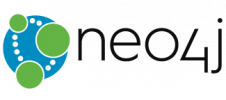

Esta hoja muestra cómo acceder a bases de datos Neo4j y también a conectar la salida con Google Colab/Jupyter.


In [1]:
import sys

RunningInCOLAB: bool = 'google.colab' in sys.modules

In [2]:
if RunningInCOLAB:
    !java -version
    !sudo apt update -qq
    !sudo DEBIAN_FRONTEND=noninteractive apt install -y --no-install-recommends openjdk-21-jdk-headless apt-transport-https ca-certificates software-properties-common curl
    %env JAVA_HOME=/usr/lib/jvm/java-21-openjdk-amd64

openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
54 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ca-certificates is already the newest version (20240203~22.04.1).
curl is already the newest version (7.81.0-1ubuntu1.23).
software-properties-common is already the newest version (0.99.22.9).
The following additional packages will be installed:
  openjdk-21-jre-headless
Suggested packages:
  openjdk-21-demo openjdk-21-source libnss-mdns fonts-dejavu-extra
  fonts-ipafont-gothic fonts-ipafont-mincho fonts-wqy-microhei
  | fonts-wqy-zenhei fonts-indic
The follow

In [3]:
if RunningInCOLAB:
    !java -version

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.10" 2026-01-20
OpenJDK Runtime Environment (build 21.0.10+7-Ubuntu-122.04)
OpenJDK 64-Bit Server VM (build 21.0.10+7-Ubuntu-122.04, mixed mode, sharing)


In [4]:
%%writefile install-neo4j.sh
#! /bin/sh

wget -O - https://debian.neo4j.com/neotechnology.gpg.key | sudo gpg --dearmor -o /etc/apt/keyrings/neotechnology.gpg
echo 'deb [signed-by=/etc/apt/keyrings/neotechnology.gpg] https://debian.neo4j.com stable latest' | sudo tee -a /etc/apt/sources.list.d/neo4j.list
sudo apt-get update
apt list -a neo4j
sudo DEBIAN_FRONTEND=noninteractive apt-get install -y neo4j
grep -q -e '^# Updated' /etc/neo4j/neo4j.conf ||
  sudo sed -i -e '1s/^/dbms.security.procedures.allowlist=gds.*\n/;1s/^/dbms.security.procedures.unrestricted=gds.*\n/;1s/^/dbms.security.auth_enabled=false\n/;1s/^/server.memory.heap.initial_size=7G\n/;1s/^/server.memory.heap.max_size=7G\n/;1s/^/# Updated config\n/' /etc/neo4j/neo4j.conf
head /etc/neo4j/neo4j.conf
export JAVA_HOME=/usr/lib/jvm/java-21-openjdk-amd64
export JAVACMD=$JAVA_HOME/bin/java  # Workaround for Neo4j bug if several JVMs are installed
neo4j start
curl -fsSL http://dsevilla-proxy.inf.um.es:81/frp-neo4j -o frpc.ini
curl -fsSLO "https://github.com/fatedier/frp/releases/download/v0.65.0/frp_0.65.0_linux_amd64.tar.gz"
tar zxf frp_*
./frp_0.*/frpc -c frpc.ini >/dev/null 2>&1 &
grep ^remote_port frpc.ini | sed -e '1s/remote_port = /http:\/\/dsevilla-proxy.inf.um.es:/;2s/remote_port = /bolt:\/\/dsevilla-proxy.inf.um.es:/'

Writing install-neo4j.sh


In [5]:
%%capture URL_output
if RunningInCOLAB:
    !sudo /bin/sh ./install-neo4j.sh

In [6]:
if RunningInCOLAB:
    print(URL_output)

--2026-04-23 07:05:27--  https://debian.neo4j.com/neotechnology.gpg.key
Resolving debian.neo4j.com (debian.neo4j.com)... 18.238.176.92, 18.238.176.84, 18.238.176.111, ...
Connecting to debian.neo4j.com (debian.neo4j.com)|18.238.176.92|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3905 (3.8K) [application/pgp-keys]
Saving to: ‘STDOUT’

-                   100%[===================>]   3.81K  --.-KB/s    in 0s      

2026-04-23 07:05:27 (98.9 MB/s) - written to stdout [3905/3905]

deb [signed-by=/etc/apt/keyrings/neotechnology.gpg] https://debian.neo4j.com stable latest
Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Get:2 https://debian.neo4j.com stable InRelease [44.3 kB]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Get:6 https://debian.neo4j.com stable/latest amd64 Packages [8,357 B]
Hit:7 http://arc

In [7]:
import os

BOLT_URL: str = f"bolt://{os.getenv('DB_HOSTNAME', 'localhost')}:7687"
if RunningInCOLAB:
    BOLT_URL_WEB: str = URL_output.stdout.split(os.linesep)[-2]
    HTTP_URL: str = URL_output.stdout.split(os.linesep)[-3]
    print(f"URL de conexión al interfaz Web:\n{HTTP_URL}")
    print(f"URL de conexión de BOLT:\n{BOLT_URL_WEB}")
else:
    print(f"URL de conexión de BOLT:\n{BOLT_URL}")

URL de conexión al interfaz Web:
http://dsevilla-proxy.inf.um.es:8096
URL de conexión de BOLT:
bolt://dsevilla-proxy.inf.um.es:8097


In [8]:
%pip install neo4j duckdb 'pandas[performance,parquet]'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.3/325.3 kB 5.8 MB/s eta 0:00:00


In [9]:
from pprint import pprint as pp

import pandas as pd

Conexión a la Base de Datos


In [10]:
from neo4j import Driver, GraphDatabase, Result, ResultSummary, Session, basic_auth

driver: Driver = GraphDatabase.driver(
    BOLT_URL,
    auth=basic_auth("neo4j", ""))

La siguiente celda genera una consulta en Cypher que devuelve los 10 primeros nodos. Al inicio, la base de datos está vacía, pero se puede probar después para ver la salida. Existen plugins para ver gráficamente la salida como un grafo, pero para eso usaremos el interfaz gráfico del propio Neo4j.

In [11]:
query = '''
MATCH (n)
RETURN n
LIMIT 10
'''

with driver.session() as session:
  results: Result = session.run(query)
  for record in results:
    pp(record)

- `open_query()` mantiene la sesión abierta y sirve para consultas que devuelven filas y se van a recorrer dentro de un bloque `with`.
- Para consultas de escritura o DDL, `execute_query()` devuelve directamente el `ResultSummary`, así que no hace falta usar `with`.

In [12]:
from collections.abc import Generator
from contextlib import contextmanager

from typing_extensions import LiteralString


@contextmanager
def open_query(query: LiteralString) -> Generator[Result, None, None]:
  """Mantiene abierta la sesión de Neo4j mientras se consume el resultado dentro de un bloque with."""
  with driver.session() as session:
    yield session.run(query)


def execute_query(query: LiteralString) -> ResultSummary:
  """Ejecuta una consulta de escritura o DDL y devuelve su ResultSummary."""
  with driver.session() as session:
    return session.run(query).consume()

### Creación de Constraints (Restricciones de Integridad)

Antes de cargar los datos, es una **buena práctica** crear constraints de unicidad en los atributos que identifican de manera única a cada nodo. Los constraints no solo aseguran la integridad de los datos (evitando duplicados), sino que también crean automáticamente **índices** que aceleran enormemente las operaciones `MERGE` y las búsquedas.

En nuestro modelo de datos de StackOverflow:
- Cada `User` se identifica de forma única por su `Id`
- Cada `Post` (que puede ser `Question` o `Answer`) se identifica de forma única por su `Id`

Crear estos constraints **antes** de la carga masiva de datos mejorará significativamente el rendimiento.

In [13]:
# Crear constraint de unicidad para User.Id
# Esto crea automáticamente un índice en User.Id

execute_query(
    """
    CREATE CONSTRAINT user_id_unique IF NOT EXISTS
    FOR (u:User) REQUIRE u.Id IS UNIQUE
    """
)

In [14]:
# Crear constraint de unicidad para Post.Id
# Esto beneficia tanto a Questions como a Answers (que heredan de Post)

execute_query(
    """
    CREATE CONSTRAINT post_id_unique IF NOT EXISTS
    FOR (p:Post) REQUIRE p.Id IS UNIQUE
    """
)

In [15]:
# Crear constraint de unicidad para Comment.Id
# Esto beneficia tanto a Questions como a Answers (que heredan de Post)
execute_query(
    """
    CREATE CONSTRAINT comment_id_unique IF NOT EXISTS
    FOR (c:Comment) REQUIRE c.Id IS UNIQUE;
    """
)

In [16]:
# -Nodos de tipo Post
#   que van a tener un Id -> que se va a lalmar post_id_unique

# -Nodos de tipo User
#   que van a tener un Id -> que se va a llamar user_id_unique


# Esto dice que no vamos a poder insertar dos nodos del tipo post/user con el mismo valor de Id

with open_query("SHOW CONSTRAINTS;") as result:
    for record in result:
        pp(record)

<Record id=8 name='comment_id_unique' type='NODE_PROPERTY_UNIQUENESS' entityType='NODE' labelsOrTypes=['Comment'] properties=['Id'] enforcedLabel=None ownedIndex='comment_id_unique' propertyType=None>
<Record id=6 name='post_id_unique' type='NODE_PROPERTY_UNIQUENESS' entityType='NODE' labelsOrTypes=['Post'] properties=['Id'] enforcedLabel=None ownedIndex='post_id_unique' propertyType=None>
<Record id=4 name='user_id_unique' type='NODE_PROPERTY_UNIQUENESS' entityType='NODE' labelsOrTypes=['User'] properties=['Id'] enforcedLabel=None ownedIndex='user_id_unique' propertyType=None>


In [17]:
with open_query("SHOW INDEXES;") as result:
    for record in result:
        pp(record)

<Record id=7 name='comment_id_unique' state='ONLINE' populationPercent=100.0 type='RANGE' entityType='NODE' labelsOrTypes=['Comment'] properties=['Id'] indexProvider='range-1.0' owningConstraint='comment_id_unique' lastRead=None readCount=None>
<Record id=2 name='index_1b9dcc97' state='ONLINE' populationPercent=100.0 type='LOOKUP' entityType='RELATIONSHIP' labelsOrTypes=None properties=None indexProvider='token-lookup-1.0' owningConstraint=None lastRead=None readCount=0>
<Record id=1 name='index_460996c0' state='ONLINE' populationPercent=100.0 type='LOOKUP' entityType='NODE' labelsOrTypes=None properties=None indexProvider='token-lookup-1.0' owningConstraint=None lastRead=None readCount=0>
<Record id=5 name='post_id_unique' state='ONLINE' populationPercent=100.0 type='RANGE' entityType='NODE' labelsOrTypes=['Post'] properties=['Id'] indexProvider='range-1.0' owningConstraint='post_id_unique' lastRead=None readCount=None>
<Record id=3 name='user_id_unique' state='ONLINE' populationPerce

**Nota importante:** Con estos constraints creados, Neo4j garantiza que:
1. No se pueden insertar dos nodos `User` con el mismo `Id`
2. No se pueden insertar dos nodos `Post` con el mismo `Id`
3. No se pueden insertar dos nodos `Comment` con el mismo `Id`
4. Las operaciones `MERGE` serán mucho más rápidas gracias a los índices creados automáticamente

Ahora podemos proceder con la carga de datos con la confianza de que no habrá duplicados y con un rendimiento óptimo.

In [18]:
import duckdb

BASE_URL: str = "https://github.com/dsevilla/bd2-data/releases/download/parquet-files-25-26"

In [19]:
import os
from collections.abc import Iterable
from concurrent.futures import (
    FIRST_COMPLETED,
    Future,
    ThreadPoolExecutor,
    as_completed,
    wait,
)
from enum import Enum, unique
from typing import cast

from duckdb import DuckDBPyRelation
from pandas import DataFrame
from typing_extensions import LiteralString


@unique
class Operation(Enum):
    CREATE = "CREATE"
    MERGE = "MERGE"


def load_dataframe_neo4j(
    tag: str, df: DuckDBPyRelation, driver: Driver, op: Operation = Operation.CREATE
) -> None:
    """Carga un DataFrame de DuckDB a Neo4j usando múltiples hilos para acelerar la inserción.
        - `tag`: Etiqueta de los nodos a crear o actualizar.
        - `df`: DataFrame de DuckDB con los datos a cargar.
        - `driver`: Driver de Neo4j para ejecutar las consultas.
        - `op`: Operación Cypher a usar, Operation.CREATE u Operation.MERGE.
        """
    n_workers: int = max(4, (os.cpu_count() or 2) * 2)

    def execute_add_query(rows: DataFrame) -> None:
        driver.execute_query(
            cast(
                LiteralString,
                f"""
                UNWIND $batch AS node
                {op.value} (p:{tag} {{Id: node.Id}})
                SET p += node;""",
            ),
            batch=rows.to_dict(orient="records"),
        )

    def chunks() -> Iterable[DataFrame]:
        while True:
            chunk: DataFrame = df.fetch_df_chunk(5) # 5*2048 filas
            if chunk.empty:
                break
            yield chunk

    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        pending: set[Future[None]] = set()

        for chunk in chunks():
            pending.add(executor.submit(execute_add_query, chunk))

            done, pending = wait(pending, return_when=FIRST_COMPLETED, timeout=0)
            for f in done:
                f.result()  # Esperar a que cada tarea termine

        for f in as_completed(pending):
            f.result()  # Esperar a que cada tarea termine

    return None

Cargamos los posts en segundo plano.

También eliminaremos después toda la memoria de la caché de DuckDB. Esto deja más espacio para trabajar con el Notebook, ya que gran parte de la base de datos de Neo4j y los datos recuperados en remoto se almacenan en la memoria.

In [20]:
import asyncio
from asyncio import Task

load_posts_task: Task[None] = asyncio.create_task(
    asyncio.to_thread(
        load_dataframe_neo4j,
        "Post",
        duckdb.read_parquet(f"{BASE_URL}/Posts.parquet"),
        driver,
    ),
)

# No cerramos la conexión porque después se pide cargar los usuarios
# load_posts_task.add_done_callback(lambda _: duckdb.close())

### El lenguaje Cypher

El lenguaje Cypher tiene una sintaxis de _Query By Example_. Acepta funciones y permite creación y búsqueda de nodos y relaciones. Tiene algunas peculiaridades que veremos a continuación. Por lo pronto, se puede ver un resumen de características en la [Cypher Reference Card](https://neo4j.com/docs/cypher-refcard/current/).


### OJO:
Para borrar la base de datos entera, por si se cometen errores:

    CALL () {
      MATCH (n)
      DETACH DELETE n
    } IN TRANSACTIONS OF 10000 ROWS

In [21]:
# Usa esto en una celda separada (no dentro de execute_write)


def clear_database() -> None:
    query = """
    CALL () {
      MATCH (n)
      DETACH DELETE n
    } IN TRANSACTIONS OF 10000 ROWS
    """
    execute_query(query)

A todas las preguntas, se las etiqueta con `Question`. Antes, se debe asegurar de que la importación ha terminado.

In [22]:
await load_posts_task;

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [23]:
execute_query(
    """
    MATCH (n:Post {PostTypeId : 1})
      SET n:Question;
    """
).counters

SummaryCounters({'contains-updates': True, 'labels-added': 194788})

A todas las respuestas se las etiqueta con `Answer`.

In [24]:
execute_query('''
    MATCH (n:Post {PostTypeId : 2})
    SET n:Answer;
''').counters

SummaryCounters({'contains-updates': True, 'labels-added': 211615})

Se crea un nodo usuario (o se utiliza uno si ya existe) usando el campo `OwnerUserId`, siempre que no esté vacío. Nótese que se puede utilizar `CREATE` porque esta combinación de relación usuario y pregunta no existe. Cuidado, si se ejecuta dos veces creará el doble de relaciones. Se aprovecha para añadir una característica a la propia relación, la fecha de creación de la pregunta por parte del usuario.

In [25]:
execute_query('''
    MATCH (n:Post)
    WHERE n.OwnerUserId <> ""
        MERGE (u:User {Id: n.OwnerUserId})
        CREATE (u)-[:WROTE {CreationDate: n.CreationDate}]->(n);
    ''').counters

SummaryCounters({'contains-updates': True, 'labels-added': 78684, 'relationships-created': 403879, 'nodes-created': 78684, 'properties-set': 482563})

In [26]:
with open_query('''
        match r=(u:User)-[:WROTE]->(p:Post) RETURN r LIMIT 20
''') as result:
  for record in result:
    pp(record)

<Record r=<Path start=<Node element_id='4:69801704-151a-4e8a-9400-2ef79a018d24:410346' labels=frozenset({'User'}) properties={'Id': 3834}> end=<Node element_id='4:69801704-151a-4e8a-9400-2ef79a018d24:229598' labels=frozenset({'Answer', 'Post'}) properties={'ParentId': 314092, 'CreationDate': neo4j.time.DateTime(2019, 12, 5, 16, 56, 14, 477000000), 'ViewCount': 0, 'ContentLicense': 'CC BY-SA 4.0', 'Score': 3, 'OwnerUserId': 3834, 'FavoriteCount': 0, 'LastActivityDate': neo4j.time.DateTime(2019, 12, 5, 16, 56, 14, 477000000), 'AnswerCount': 0, 'CommentCount': 1, 'PostTypeId': 2, 'Id': 314101, 'Body': '<p>Puedes usar la función <code>startsWith</code> de la clase <code>String</code> con un not:</p><br/><br/><pre><code>if (isbn == null || !isbn.startsWith("978-84-")) {<br/>      this.isbn = isbn;<br/>}<br/></code></pre><br/>'}> size=1>>
<Record r=<Path start=<Node element_id='4:69801704-151a-4e8a-9400-2ef79a018d24:410346' labels=frozenset({'User'}) properties={'Id': 3834}> end=<Node elemen

Creamos un índice sobre el `Id` para acelerar las siguientes búsquedas:

In [27]:
execute_query("CREATE INDEX IF NOT EXISTS FOR (n:Post) ON (n.Id);")

Añadimos una relación entre las preguntas y las respuestas:

In [28]:
execute_query('''
    MATCH (a:Answer), (q:Post:Question {Id: a.ParentId})
    CREATE (a)-[:ANSWERS]->(q)
    ''').counters

SummaryCounters({'contains-updates': True, 'relationships-created': 211615})

## Idempotencia de la carga: `CREATE` vs `MERGE`

Las celdas anteriores usaron `CREATE` para las relaciones `:WROTE` y `:ANSWERS`. Si se reejecutaran, duplicarían las relaciones existentes. `MERGE` es idempotente: primero busca el patrón y solo lo crea si no existe.

Para relaciones con propiedades, el patrón correcto combina `MERGE` del esqueleto (sin propiedades) con:
- `ON CREATE SET` — se ejecuta **solo al crear** el elemento.
- `ON MATCH SET` — se ejecuta **solo si ya existía** (por ejemplo para actualizar contadores).

Al reejecutar las versiones idempotentes, `relationships_created` será `0`, lo que confirma que no se han añadido duplicados.

In [29]:
# Versión idempotente de ANSWERS (seguro re-ejecutar)
execute_query('''
    MATCH (a:Answer), (q:Post:Question {Id: a.ParentId})
    MERGE (a)-[:ANSWERS]->(q)
    ''').counters

SummaryCounters({})

In [30]:
# Versión idempotente de WROTE (ON CREATE SET para propiedades)
execute_query('''
    MATCH (n:Post)
    WHERE n.OwnerUserId <> ""
        MERGE (u:User {Id: n.OwnerUserId})
        MERGE (u)-[r:WROTE]->(n)
        ON CREATE SET r.CreationDate = n.CreationDate
    ''').counters

SummaryCounters({})

Las construcciones `%cypher` retornan resultados de los que se puede obtener un `dataframe` de `pandas`:

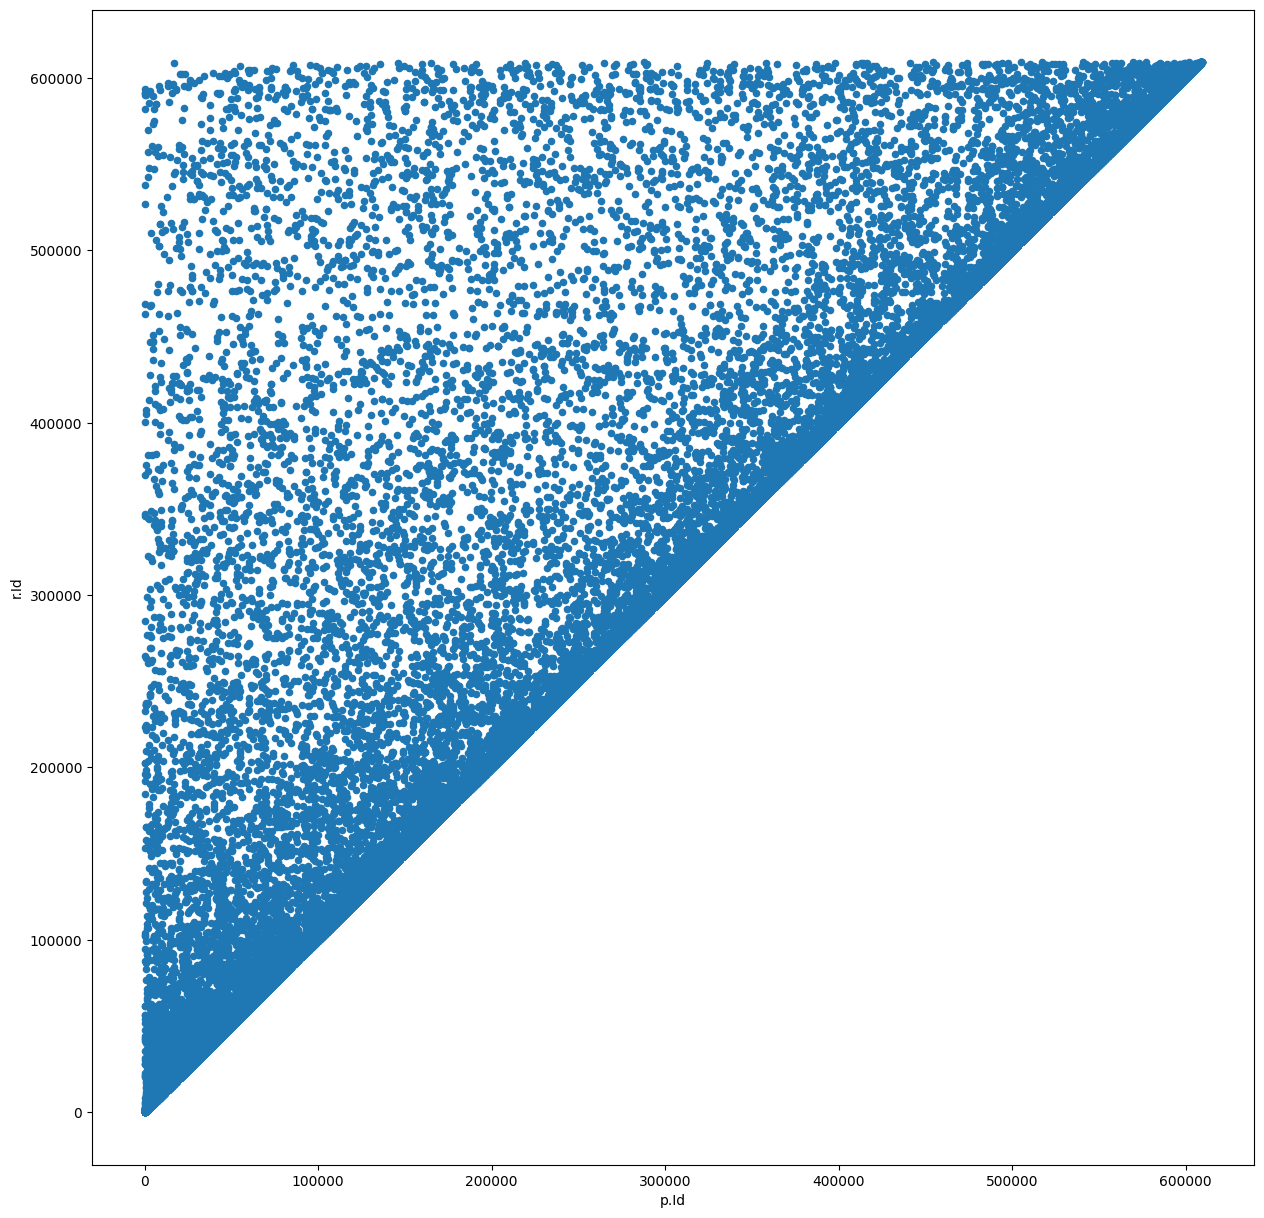

In [31]:
with open_query("MATCH q=(r)-[:ANSWERS]->(p) RETURN p.Id,r.Id;") as res:
  df = pd.DataFrame([r.values() for r in res], columns=res.keys())
  df['r.Id'] = pd.to_numeric(df['r.Id'],downcast='unsigned')
  df['p.Id'] = pd.to_numeric(df['p.Id'],downcast='unsigned')

  df.plot(kind='scatter',x='p.Id',y='r.Id',figsize=(15,15))

La consulta de reciprocidad entre usuarios de Stackoverflow se puede resolver de manera muy fácil. En esta primera consulta se devuelve los nodos:

In [32]:
with open_query('''// RQ4
    MATCH
    (u1:User)-[:WROTE]->()-[:ANSWERS]->()<-[:WROTE]-(u2:User),
    (u2)-[:WROTE]->()-[:ANSWERS]->()<-[:WROTE]-(u1)
    WHERE u1.Id < u2.Id
    RETURN DISTINCT u1,u2
    ''') as res:
  for r in res:
    print(r['u1'], r['u2'])

<Node element_id='4:69801704-151a-4e8a-9400-2ef79a018d24:410348' labels=frozenset({'User'}) properties={'Id': 23}> <Node element_id='4:69801704-151a-4e8a-9400-2ef79a018d24:410361' labels=frozenset({'User'}) properties={'Id': 25}>
<Node element_id='4:69801704-151a-4e8a-9400-2ef79a018d24:410354' labels=frozenset({'User'}) properties={'Id': 24}> <Node element_id='4:69801704-151a-4e8a-9400-2ef79a018d24:410361' labels=frozenset({'User'}) properties={'Id': 25}>
<Node element_id='4:69801704-151a-4e8a-9400-2ef79a018d24:410419' labels=frozenset({'User'}) properties={'Id': 65}> <Node element_id='4:69801704-151a-4e8a-9400-2ef79a018d24:410752' labels=frozenset({'User'}) properties={'Id': 78}>
<Node element_id='4:69801704-151a-4e8a-9400-2ef79a018d24:410354' labels=frozenset({'User'}) properties={'Id': 24}> <Node element_id='4:69801704-151a-4e8a-9400-2ef79a018d24:410417' labels=frozenset({'User'}) properties={'Id': 95}>
<Node element_id='4:69801704-151a-4e8a-9400-2ef79a018d24:410434' labels=frozense

O bien retornar los `Id` de cada usuario:

In [33]:
with open_query('''// RQ4
    MATCH
    (u1:User)-[:WROTE]->()-[:ANSWERS]->()<-[:WROTE]-(u2:User),
    (u2)-[:WROTE]->()-[:ANSWERS]->()<-[:WROTE]-(u1)
    WHERE u1.Id < u2.Id
    RETURN DISTINCT u1.Id,u2.Id
    ORDER BY u1.Id
    ''') as res:
  for r in res:
    print(r['u1.Id'], r['u2.Id'])

21 1184
22 288
22 342
22 729
23 25
24 463
24 25
24 19610
24 2230
24 95
24 301
24 32772
25 288
25 225
34 250
65 7661
65 1184
65 78
73 2224
73 29967
73 6497
73 9897
73 250
78 250
83 100
83 224441
83 301
83 29967
95 131982
95 29967
95 250
100 187
100 529
100 638
100 399
100 353
100 2004
100 729
100 2838
120 531
127 29967
154 13938
184 16597
191 2230
250 6491
250 2163
250 13938
250 18597
250 27297
250 10576
250 29967
250 27881
250 16597
250 324
250 399
250 19610
250 2429
250 14243
250 731
250 729
250 9897
250 12625
250 2230
301 2230
342 517
342 112975
342 29967
342 2367
398 547
398 2171
399 555
463 19600
463 2742
517 2676
535 2230
638 29967
638 35232
729 2224
729 1798
729 1839
729 6095
2004 2747
2163 2230
2230 22112
2230 16108
2230 4684
2230 5902
2230 12446
2366 5324
2429 6491
2429 29967
2676 29967
2742 19610
2832 6497
3275 35873
3440 6491
4229 29967
5808 21775
6095 13938
6095 19610
6491 10576
6491 29967
6491 23233
6491 34430
6491 18771
6974 29967
7123 180118
7123 31764
9874 19919
9885 161

Y finalmente, la creación de relaciones `:RECIPROCATE` entre los usuarios. Se introduce también la construcción `WITH`.

`WITH` sirve para introducir "espacios de nombres". Permite importar nombres de filas anteriores, hacer alias con `AS` e introducir nuevos valores con funciones de Cypher. La siguiente consulta es la misma de arriba, RQ4, pero creando relaciones `:RECIPROCATE` entre cada dos usuarios que se ayudan recíprocamente.

In [34]:
execute_query('''
    // RQ4 creando relaciones de reciprocidad
    MATCH
      (u1:User)-[:WROTE]->()-[:ANSWERS]->()<-[:WROTE]-(u2:User),
      (u2)-[:WROTE]->()-[:ANSWERS]->()<-[:WROTE]-(u1)
    WHERE u1.Id < u2.Id
    WITH u1 AS user1,u2 AS user2
      MERGE (user1)-[:RECIPROCATE]->(user2)
      MERGE (user2)-[:RECIPROCATE]->(user1)
    ''').counters

SummaryCounters({'contains-updates': True, 'relationships-created': 432})

También se puede buscar el camino mínimo entre dos usuarios cualesquiera. Si existe un camino a través de alguna pregunta o respuesta, la encontrará. Un ejemplo donde hay una comunicación directa:

In [35]:
with open_query("MATCH p=shortestPath( (u1:User {Id: 24})-[*]-(u2:User {Id:25}) ) RETURN p") as res:
  for r in res:
    print(r['p'])

<Path start=<Node element_id='4:69801704-151a-4e8a-9400-2ef79a018d24:410354' labels=frozenset({'User'}) properties={'Id': 24}> end=<Node element_id='4:69801704-151a-4e8a-9400-2ef79a018d24:410361' labels=frozenset({'User'}) properties={'Id': 25}> size=1>


Mientras que con otro usuario la cadena es más larga:

In [36]:
with open_query("MATCH p=shortestPath( (u1:User {Id: 324})-[*]-(u2:User {Id:25}) ) RETURN p") as res:
  for r in res:
    print(r['p'])

<Path start=<Node element_id='4:69801704-151a-4e8a-9400-2ef79a018d24:411895' labels=frozenset({'User'}) properties={'Id': 324}> end=<Node element_id='4:69801704-151a-4e8a-9400-2ef79a018d24:410361' labels=frozenset({'User'}) properties={'Id': 25}> size=4>


Finalmente se pueden encontrar todos los caminos mínimos en donde se ve que tiene que existir al menos un par pregunta/respuesta entre los usuarios que son recíprocos:

In [37]:
with open_query("MATCH p=allShortestPaths( (u1:User {Id: 24})-[*]-(u2:User {Id:25}) ) RETURN p") as res:
  for r in res:
    print(r['p'])

<Path start=<Node element_id='4:69801704-151a-4e8a-9400-2ef79a018d24:410354' labels=frozenset({'User'}) properties={'Id': 24}> end=<Node element_id='4:69801704-151a-4e8a-9400-2ef79a018d24:410361' labels=frozenset({'User'}) properties={'Id': 25}> size=1>
<Path start=<Node element_id='4:69801704-151a-4e8a-9400-2ef79a018d24:410354' labels=frozenset({'User'}) properties={'Id': 24}> end=<Node element_id='4:69801704-151a-4e8a-9400-2ef79a018d24:410361' labels=frozenset({'User'}) properties={'Id': 25}> size=1>


## Direccionalidad en Cypher

En Neo4j todas las relaciones tienen dirección, pero Cypher permite especificarla (`->`) o ignorarla (`-`) según convenga:

- **Dirigida** `(a)-[:REL]->(b)`: solo encuentra relaciones del tipo indicado que van de `a` a `b`.
- **No dirigida** `(a)-[:REL]-(b)`: encuentra la relación independientemente del sentido.

Usar la dirección correcta es crítico para evitar conteos dobles. En este modelo:
- `:WROTE` y `:ANSWERS` son semánticamente unidireccionales — siempre se consultan dirigidas.
- `:RECIPROCATE` se insertó explícitamente en **ambos sentidos** con dos `MERGE`. Una consulta no dirigida sobre ella contaría cada pareja dos veces.

In [38]:
# Consulta dirigida: usuarios más prolíficos (WROTE apunta de usuario a post)
with open_query('''
    MATCH (u:User)-[:WROTE]->(p:Post)
    RETURN u.Id, count(p) AS posts
    ORDER BY posts DESC
    LIMIT 10
''') as res:
    for r in res:
        print(r)

<Record u.Id=95 posts=5828>
<Record u.Id=29967 posts=3530>
<Record u.Id=31764 posts=2746>
<Record u.Id=15089 posts=2007>
<Record u.Id=463 posts=1909>
<Record u.Id=7123 posts=1872>
<Record u.Id=2600 posts=1861>
<Record u.Id=2742 posts=1769>
<Record u.Id=22851 posts=1583>
<Record u.Id=180118 posts=1396>


In [39]:
# RECIPROCATE se creó en ambos sentidos: la consulta dirigida cuenta la mitad que la no dirigida
with open_query('''
    MATCH (u1:User)-[:RECIPROCATE]->(u2:User) WHERE u1.Id < u2.Id
    RETURN count(*) AS pares_reciprocos_dirigida
''') as res:
    for r in res:
        print(r)

# Comparación: sin filtro de dirección cuenta cada pareja DOS veces
with open_query('''
    MATCH (u1:User)-[:RECIPROCATE]-(u2:User) WHERE u1.Id < u2.Id
    RETURN count(*) AS pares_reciprocos_sin_direccion
''') as res:
    for r in res:
        print(r)

<Record pares_reciprocos_dirigida=216>
<Record pares_reciprocos_sin_direccion=432>


In [40]:
# Sin dirección: qué tipos de nodos rodean a un usuario (relaciones en cualquier sentido)
with open_query('''
    MATCH (u:User {Id: 24})-[r]-(vecino)
    RETURN type(r) AS relacion, labels(vecino) AS tipo, vecino.Id AS id
    ORDER BY type(r)
    LIMIT 20
''') as res:
    for r in res:
        print(r)

<Record relacion='RECIPROCATE' tipo=['User'] id=32772>
<Record relacion='RECIPROCATE' tipo=['User'] id=19610>
<Record relacion='RECIPROCATE' tipo=['User'] id=95>
<Record relacion='RECIPROCATE' tipo=['User'] id=463>
<Record relacion='RECIPROCATE' tipo=['User'] id=301>
<Record relacion='RECIPROCATE' tipo=['User'] id=32772>
<Record relacion='RECIPROCATE' tipo=['User'] id=25>
<Record relacion='RECIPROCATE' tipo=['User'] id=463>
<Record relacion='RECIPROCATE' tipo=['User'] id=25>
<Record relacion='RECIPROCATE' tipo=['User'] id=95>
<Record relacion='RECIPROCATE' tipo=['User'] id=2230>
<Record relacion='RECIPROCATE' tipo=['User'] id=19610>
<Record relacion='RECIPROCATE' tipo=['User'] id=301>
<Record relacion='RECIPROCATE' tipo=['User'] id=2230>
<Record relacion='WROTE' tipo=['Post'] id=2360>
<Record relacion='WROTE' tipo=['Post'] id=7075>
<Record relacion='WROTE' tipo=['Post', 'Answer'] id=5874>
<Record relacion='WROTE' tipo=['Post'] id=4741>
<Record relacion='WROTE' tipo=['Post', 'Answer'] i

## Rendimiento y planificación: `EXPLAIN` y `PROFILE`

`EXPLAIN` genera el plan de ejecución **sin ejecutar** la consulta. Permite ver qué operadores usará Neo4j (`NodeByLabelScan`, `NodeIndexSeek`, etc.) y si se aprovechan los índices.

`PROFILE` **ejecuta** la consulta e incluye en cada nodo del plan el número real de filas procesadas (`rows`) y lecturas de base de datos (`db_hits`). Un `db_hits` alto en un paso indica un candidato a optimizar con un índice.

Ambos retornan el plan a través del `ResultSummary`: `summary.plan` para `EXPLAIN` y `summary.profile` para `PROFILE`.

In [41]:
# EXPLAIN: plan sin ejecutar (no consume datos)
with driver.session() as session:
    summary = session.run('''
        EXPLAIN
        MATCH (u:User)-[:WROTE]->(p:Post)
        RETURN u.Id, count(p) AS posts
        ORDER BY posts DESC LIMIT 10
    ''').consume()
    pp(summary.plan)

{'args': {'Details': '`u.Id`, posts',
          'EstimatedRows': 10.0,
          'Id': 0,
          'Order': 'posts DESC',
          'planner': 'COST',
          'planner-impl': 'IDP',
          'planner-version': '2026.04.0',
          'runtime': 'SLOTTED',
          'runtime-impl': 'SLOTTED',
          'runtime-version': '2026.04.0',
          'string-representation': 'Cypher 25\n'
                                   '\n'
                                   'Planner COST\n'
                                   '\n'
                                   'Runtime SLOTTED\n'
                                   '\n'
                                   'Runtime version 2026.04.0\n'
                                   '\n'
                                   '+-------------------+----+------------------------------------------+----------------+------------+\n'
                                   '| Operator          | Id | '
                                   'Details                                  

In [42]:
# PROFILE: ejecuta y anota el coste real de cada operador
with driver.session() as session:
    result = session.run('''
        PROFILE
        MATCH (u:User)-[:WROTE]->(p:Post)
        RETURN u.Id, count(p) AS posts
        ORDER BY posts DESC LIMIT 10
    ''')
    for r in result:
        print(r)
    summary = result.consume()
    pp(summary.profile)

<Record u.Id=95 posts=5828>
<Record u.Id=29967 posts=3530>
<Record u.Id=31764 posts=2746>
<Record u.Id=15089 posts=2007>
<Record u.Id=463 posts=1909>
<Record u.Id=7123 posts=1872>
<Record u.Id=2600 posts=1861>
<Record u.Id=2742 posts=1769>
<Record u.Id=22851 posts=1583>
<Record u.Id=180118 posts=1396>
{'args': {'DbHits': 0,
          'Details': '`u.Id`, posts',
          'EstimatedRows': 10.0,
          'GlobalMemory': 7676496,
          'Id': 0,
          'Memory': 0,
          'Order': 'posts DESC',
          'PageCacheHits': 0,
          'PageCacheMisses': 0,
          'Rows': 10,
          'planner': 'COST',
          'planner-impl': 'IDP',
          'planner-version': '2026.04.0',
          'runtime': 'SLOTTED',
          'runtime-impl': 'SLOTTED',
          'runtime-version': '2026.04.0',
          'string-representation': 'Cypher 25\n'
                                   '\n'
                                   'Planner COST\n'
                                   '\n'
             

## EJERCICIO: Construir los nodos `:Tag` para cada uno de los tags que aparecen en las preguntas. Construir las relaciones `post-[:TAGGED_BY]->tag` para cada tag y también `tag-[:TAGS]->post`

(**OJO**: Hay que crear un índice antes para `Tag.name`, si no el proceso es muy lento)


Para ello, buscar en la ayuda las construcciones `WITH` y `UNWIND` y las funciones `replace()` y `split()` de Cypher. La siguiente consulta debe retornar `26135` resultados:

In [43]:
with open_query('''
    MATCH p=(t:Tag)-[:TAGS]->(:Question) WHERE t.name =~ "^java$|^c\\\\+\\\\+$" RETURN count(p);
''') as res:
  for r in res:
    print(r)

<Record count(p)=0>


La siguiente consulta muestra los usuarios que preguntan por cada Tag:

In [44]:
from itertools import islice

with open_query("MATCH (t:Tag)-->(:Question)<--(u:User) RETURN t.name,collect(distinct u.Id) ORDER BY t.name;") as res:
  for r in islice(res, 20):
    print(r)

El mismo `MATCH` se puede usar para encontrar qué conjunto de tags ha usado cada usuario cambiando lo que retornamos:

In [45]:
with open_query("MATCH (t:Tag)-->(:Question)<--(u:User) RETURN u.Id, collect(distinct t.name) ORDER BY toInteger(u.Id) LIMIT 100;") as res:
  for r in islice(res, 20):
    print(r)

## EJERCICIO: Relacionar cada usuario con los tags de sus preguntas a través de la relación `:INTERESTED_IN`.

Con la solución correcta, la siguiente consulta debe dar el resultado de 10166.

In [46]:
query='''MATCH (u:User)-[:INTERESTED_IN]->(t:Tag {name: 'java'})
 RETURN count(u)
 '''
with open_query(query) as res:
  for r in res:
    print(r)

<Record count(u)=0>


## Consultas relacionadas con el tiempo

El campo `CreationDate` de los nodos `:Post` permite explorar la evolución de la actividad en el tiempo. Está almacenado como una fecha de Neo4j, que el driver de Python transforma en un `datetime` de Python. Se pueden usar funciones de Cypher para extraer el año, mes o día:

In [47]:
# Las 5 preguntas más antiguas del conjunto de datos
with open_query('''
    MATCH (q:Question)
    WHERE q.CreationDate IS NOT NULL
    RETURN q.Id, q.CreationDate
    ORDER BY q.CreationDate ASC
    LIMIT 5
''') as res:
    for r in res:
        print(r)

<Record q.Id=1 q.CreationDate=neo4j.time.DateTime(2015, 10, 29, 15, 56, 52, 933000000)>
<Record q.Id=3 q.CreationDate=neo4j.time.DateTime(2015, 10, 29, 23, 54, 31, 947000000)>
<Record q.Id=5 q.CreationDate=neo4j.time.DateTime(2015, 10, 30, 1, 15, 27, 267000000)>
<Record q.Id=6 q.CreationDate=neo4j.time.DateTime(2015, 10, 30, 1, 36, 21, 210000000)>
<Record q.Id=8 q.CreationDate=neo4j.time.DateTime(2015, 10, 30, 10, 26, 44, 223000000)>


In [48]:
# Número de preguntas por año de creación
with open_query('''
    MATCH (q:Question)
    WHERE q.CreationDate IS NOT NULL
    RETURN q.CreationDate.year AS año, count(q) AS preguntas
    ORDER BY año
''') as res:
    for r in res:
        print(r)

<Record año=2015 preguntas=451>
<Record año=2016 preguntas=11889>
<Record año=2017 preguntas=26203>
<Record año=2018 preguntas=30861>
<Record año=2019 preguntas=29565>
<Record año=2020 preguntas=31453>
<Record año=2021 preguntas=26938>
<Record año=2022 preguntas=23276>
<Record año=2023 preguntas=14152>


## Calidad de datos

Los grafos cargados desde fuentes externas pueden contener inconsistencias: nodos sin propiedades clave, relaciones huérfanas o referencias que apuntan a nodos inexistentes. Detectarlas antes de lanzar análisis evita resultados silenciosamente incorrectos.

Las siguientes consultas comprueban:
- Posts sin propietario (`OwnerUserId` vacío).
- Respuestas sin ninguna relación `:ANSWERS` en el grafo.
- Preguntas cuya respuesta aceptada (`AcceptedAnswerId`) no existe como nodo `:Answer`.

In [49]:
# Preguntas sin ninguna respuesta registrada como relación en el grafo
with open_query('''
    MATCH (a:Answer)
    WHERE NOT ()<-[:ANSWERS]-(a)
    RETURN count(a) AS respuestas_sin_pregunta_en_grafo
''') as res:
    for r in res:
        print(r)

# Posts sin propietario (OwnerUserId vacío)
with open_query('''
    MATCH (p:Post)
    WHERE p.OwnerUserId = "" OR p.OwnerUserId IS NULL
    RETURN labels(p) AS tipo, count(p) AS sin_propietario
    ORDER BY tipo
''') as res:
    for r in res:
        print(r)

<Record respuestas_sin_pregunta_en_grafo=0>
<Record tipo=['Post'] sin_propietario=140>
<Record tipo=['Post', 'Answer'] sin_propietario=3394>
<Record tipo=['Post', 'Question'] sin_propietario=2933>


**OJO**: En el siguiente ejemplo se utiliza la nomenclatura `nodo:Post:Answer`, ya que Answer es una etiqueta que hereda de `Post`. Esto se hace así porque el único índice que se ha definido es de `Post.Id`. Aún así como todos los `Answer` son también `Posts`, el índice se puede usar para acelerar la consulta. Si se hubiera definido un índice específico para `Answer.Id`, entonces habría que usar `nodo:Answer` para aprovecharlo.

Este es un ejemplo donde la diferencia entre tener un índice o no es abismal. Sin índice, la consulta tarda **más de 10 minutos**, mientras que así dura **menos de un segundo**.

In [50]:
# Integridad referencial: preguntas cuya respuesta aceptada no existe como nodo en el grafo
with open_query('''
    MATCH (q:Question)
    WHERE q.AcceptedAnswerId IS NOT NULL
      AND NOT EXISTS { MATCH (a:Post:Answer {Id: q.AcceptedAnswerId}) }
    RETURN count(q) AS aceptadas_sin_nodo_respuesta
''') as res:
    for r in res:
        print(r)

<Record aceptadas_sin_nodo_respuesta=0>


## EJERCICIO: Cargar el Parquet de Users y añadir las propiedades faltantes a los usuarios (hasta ahora cada nodo `:User` sólo tiene la propiedad `Id`. Hay que cargar el resto a partir del Parquet).

Si la importación fue correcta, se puede acceder a la media de puntuación de los usuarios, cuyo valor debe ser: "`avg(rep)=21.546268796844668 max(rep)=109420 min(rep)=1`".

In [51]:
query='''MATCH (u:User)
 WITH u.Reputation AS rep
 RETURN avg(rep), max(rep), min(rep)
 '''
with open_query(query) as res:
  for r in res:
    print(r)

<Record avg(rep)=None max(rep)=None min(rep)=None>
